In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

In [2]:
# File paths
MC_CCB_FILE = Path(r"C:\Users\grzanka\workspace\osl_mb_foils\notebooks\pub_something_2026\mc\mc_ccb_big.csv")
EBT_CCB_FILE = Path(r"C:\Users\grzanka\workspace\osl_mb_foils\notebooks\pub_something_2026\ebt_foils\ebt_profile_ccb.csv")
#MBO_FILE = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2026-02-16\profile_foils_1_2.npz")
MBO_FILE = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2026-02-20\profile_foils_2_3.npz")

print(f"MC file exists: {MC_CCB_FILE.exists()}")
print(f"EBT file exists: {EBT_CCB_FILE.exists()}")
print(f"MBO file exists: {MBO_FILE.exists()}")

MC file exists: True
EBT file exists: True
MBO file exists: True


In [3]:
# Load MC data
# Columns: depth (mm), dose (normalized), fluence, kinetic_energy
df_mc = pd.read_csv(MC_CCB_FILE)

# Load EBT data
# Columns: x_mm (mm, shifted so pencil mark is at X=0), dose_Gy (Gy)
df_ebt = pd.read_csv(EBT_CCB_FILE)

# Load MBO data
mbo_data = np.load(MBO_FILE)
mbo_x_mm = mbo_data['x_mm']
mbo_values = mbo_data['profile_opt_smooth']

print("MC Data:")
print(df_mc.head())
print(f"Shape: {df_mc.shape}")
print(f"Depth range: [{df_mc['depth'].min():.2f}, {df_mc['depth'].max():.2f}] mm")
print()
print("EBT Data:")
print(df_ebt.head())
print(f"Shape: {df_ebt.shape}")
print(f"X range: [{df_ebt['x_mm'].min():.2f}, {df_ebt['x_mm'].max():.2f}] mm")
print()
print("MBO Data:")
print(f"X range: [{mbo_x_mm.min():.2f}, {mbo_x_mm.max():.2f}] mm")
print(f"Values range: [{mbo_values.min():.2f}, {mbo_values.max():.2f}]")

MC Data:
   depth      dose  dose_err   fluence  fluence_err  kinetic_energy  \
0  0.025  0.258738  0.000850  0.080143     0.000258         60.4629   
1  0.075  0.258574  0.000807  0.080145     0.000248         60.4592   
2  0.125  0.258138  0.000756  0.080005     0.000237         60.4580   
3  0.175  0.258569  0.000796  0.080036     0.000243         60.4450   
4  0.225  0.259069  0.000792  0.080206     0.000239         60.4001   

   kinetic_energy_err  
0            0.003757  
1            0.003779  
2            0.003746  
3            0.003759  
4            0.003698  
Shape: (640, 7)
Depth range: [0.02, 31.98] mm

EBT Data:
        x_mm   dose_Gy
0 -12.136225  0.121226
1 -11.966892  0.131299
2 -11.797558  0.137988
3 -11.628225  0.144432
4 -11.458892  0.145763
Shape: (264, 2)
X range: [-12.14, 32.40] mm

MBO Data:
X range: [0.00, 37.44] mm
Values range: [5.57, 1579.93]


In [4]:
# Rescale MC dose to match EBT dose at X = 0 mm
# First, interpolate both datasets at X = 0

# EBT interpolation at X = 0
ebt_interp = interp1d(df_ebt['x_mm'], df_ebt['dose_Gy'], kind='linear', fill_value='extrapolate')
ebt_dose_at_0 = float(ebt_interp(0))

# MC interpolation at X = 0 (using depth column which corresponds to x position)
mc_interp = interp1d(df_mc['depth'], df_mc['dose'], kind='linear', fill_value='extrapolate')
mc_dose_at_0 = float(mc_interp(0))

# Calculate scaling factor for MC
scale_factor_mc = ebt_dose_at_0 / mc_dose_at_0

print(f"EBT dose at X=0: {ebt_dose_at_0:.4f} Gy")
print(f"MC dose at X=0 (normalized): {mc_dose_at_0:.4f}")
print(f"MC Scale factor: {scale_factor_mc:.4f}")

# Create scaled MC dose column
df_mc['dose_scaled'] = df_mc['dose'] * scale_factor_mc
print(f"MC dose at X=0 after scaling: {float(mc_interp(0)) * scale_factor_mc:.4f} Gy")

# Shift MBO profile so max aligns with EBT max position
# Find position of max for EBT
ebt_max_idx = df_ebt['dose_Gy'].idxmax()
ebt_max_x = df_ebt.loc[ebt_max_idx, 'x_mm']

# Find position of max for MBO
mbo_max_idx = np.argmax(mbo_values)
mbo_max_x = mbo_x_mm[mbo_max_idx]

# Shift MBO x coordinates
mbo_x_shift = ebt_max_x - mbo_max_x
mbo_x_shifted = mbo_x_mm + mbo_x_shift

print(f"\nEBT max position: {ebt_max_x:.2f} mm")
print(f"MBO max position (original): {mbo_max_x:.2f} mm")
print(f"MBO shift applied: {mbo_x_shift:.2f} mm")

# Rescale MBO to match EBT dose at X = 0 mm
mbo_interp = interp1d(mbo_x_shifted, mbo_values, kind='linear', fill_value='extrapolate')
mbo_value_at_0 = float(mbo_interp(0))
scale_factor_mbo = ebt_dose_at_0 / mbo_value_at_0
mbo_values_scaled = mbo_values * scale_factor_mbo

print(f"\nMBO value at X=0 (after shift): {mbo_value_at_0:.4f}")
print(f"MBO Scale factor: {scale_factor_mbo:.6f}")
print(f"MBO dose at X=0 after scaling: {mbo_value_at_0 * scale_factor_mbo:.4f} Gy")

EBT dose at X=0: 5.0339 Gy
MC dose at X=0 (normalized): 0.2588
MC Scale factor: 19.4495
MC dose at X=0 after scaling: 5.0339 Gy

EBT max position: 26.13 mm
MBO max position (original): 30.19 mm
MBO shift applied: -4.06 mm

MBO value at X=0 (after shift): 537.0463
MBO Scale factor: 0.009373
MBO dose at X=0 after scaling: 5.0339 Gy


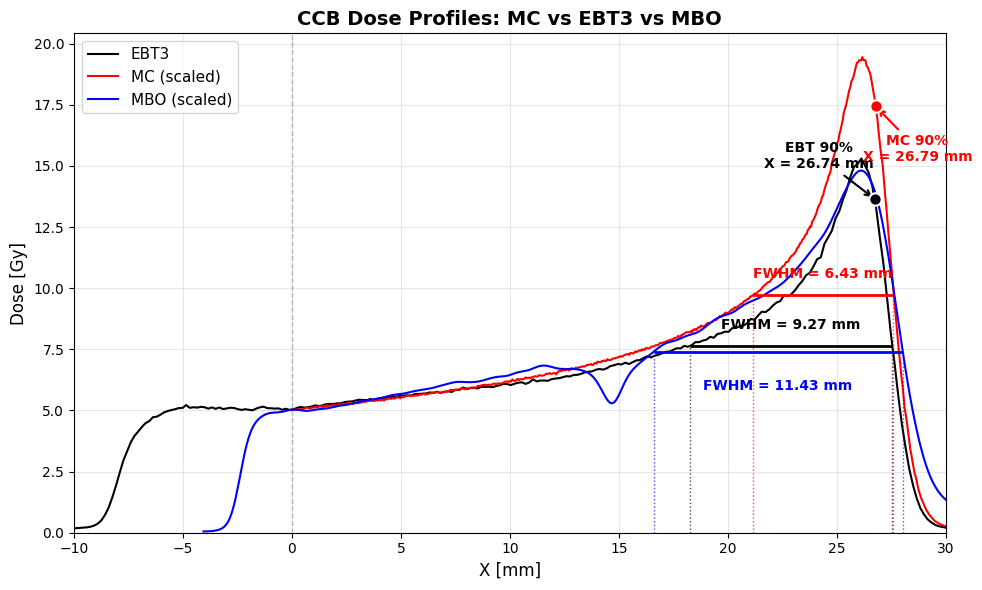

In [5]:
# Plot MC, EBT and MBO dose profiles on the same plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot EBT data (black color)
ax.plot(df_ebt['x_mm'], df_ebt['dose_Gy'], 
        color='black', linewidth=1.5, label='EBT3')

# Plot MC data (scaled, red color)
ax.plot(df_mc['depth'], df_mc['dose_scaled'], 
        color='red', linewidth=1.5, label='MC (scaled)')

# Plot MBO data (scaled and shifted, blue color)
ax.plot(mbo_x_shifted, mbo_values_scaled, 
        color='blue', linewidth=1.5, label='MBO (scaled)')

# Mark the reference point at X=0
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Create dense grids for interpolation
x_dense = np.linspace(df_ebt['x_mm'].min(), df_ebt['x_mm'].max(), 1000)
ebt_dense = ebt_interp(x_dense)

mc_interp_scaled = interp1d(df_mc['depth'], df_mc['dose_scaled'], kind='linear', fill_value='extrapolate')
x_dense_mc = np.linspace(df_mc['depth'].min(), df_mc['depth'].max(), 1000)
mc_dense = mc_interp_scaled(x_dense_mc)

# --- FWHM for EBT ---
ebt_max = df_ebt['dose_Gy'].max()
ebt_half_max = ebt_max / 2

above_half_ebt = ebt_dense >= ebt_half_max
transitions_ebt = np.diff(above_half_ebt.astype(int))
rising_idx_ebt = np.where(transitions_ebt == 1)[0]
falling_idx_ebt = np.where(transitions_ebt == -1)[0]

if len(rising_idx_ebt) > 0 and len(falling_idx_ebt) > 0:
    fwhm_left_ebt = x_dense[rising_idx_ebt[0]]
    fwhm_right_ebt = x_dense[falling_idx_ebt[-1]]
    fwhm_value_ebt = fwhm_right_ebt - fwhm_left_ebt
    
    # Draw FWHM horizontal line for EBT
    ax.hlines(y=ebt_half_max, xmin=fwhm_left_ebt, xmax=fwhm_right_ebt, 
              colors='black', linestyles='-', linewidth=2)
    ax.vlines(x=[fwhm_left_ebt, fwhm_right_ebt], ymin=0, ymax=ebt_half_max, 
              colors='black', linestyles=':', linewidth=1, alpha=0.7)
    ax.annotate(f'FWHM = {fwhm_value_ebt:.2f} mm', 
                xy=((fwhm_left_ebt + fwhm_right_ebt) / 2, ebt_half_max),
                xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, color='black',
                fontweight='bold')

# --- FWHM for MC ---
mc_max = df_mc['dose_scaled'].max()
mc_half_max = mc_max / 2

above_half_mc = mc_dense >= mc_half_max
transitions_mc = np.diff(above_half_mc.astype(int))
rising_idx_mc = np.where(transitions_mc == 1)[0]
falling_idx_mc = np.where(transitions_mc == -1)[0]

if len(rising_idx_mc) > 0 and len(falling_idx_mc) > 0:
    fwhm_left_mc = x_dense_mc[rising_idx_mc[0]]
    fwhm_right_mc = x_dense_mc[falling_idx_mc[-1]]
    fwhm_value_mc = fwhm_right_mc - fwhm_left_mc
    
    # Draw FWHM horizontal line for MC
    ax.hlines(y=mc_half_max, xmin=fwhm_left_mc, xmax=fwhm_right_mc, 
              colors='red', linestyles='-', linewidth=2)
    ax.vlines(x=[fwhm_left_mc, fwhm_right_mc], ymin=0, ymax=mc_half_max, 
              colors='red', linestyles=':', linewidth=1, alpha=0.7)
    ax.annotate(f'FWHM = {fwhm_value_mc:.2f} mm', 
                xy=((fwhm_left_mc + fwhm_right_mc) / 2, mc_half_max),
                xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, color='red',
                fontweight='bold')

# --- FWHM for MBO ---
mbo_max_val = mbo_values_scaled.max()
mbo_half_max = mbo_max_val / 2

mbo_interp_scaled = interp1d(mbo_x_shifted, mbo_values_scaled, kind='linear', fill_value='extrapolate')
x_dense_mbo = np.linspace(mbo_x_shifted.min(), mbo_x_shifted.max(), 1000)
mbo_dense = mbo_interp_scaled(x_dense_mbo)

above_half_mbo = mbo_dense >= mbo_half_max
transitions_mbo = np.diff(above_half_mbo.astype(int))
rising_idx_mbo = np.where(transitions_mbo == 1)[0]
falling_idx_mbo = np.where(transitions_mbo == -1)[0]

if len(rising_idx_mbo) > 0 and len(falling_idx_mbo) > 0:
    fwhm_left_mbo = x_dense_mbo[rising_idx_mbo[0]]
    fwhm_right_mbo = x_dense_mbo[falling_idx_mbo[-1]]
    fwhm_value_mbo = fwhm_right_mbo - fwhm_left_mbo
    
    # Draw FWHM horizontal line for MBO
    ax.hlines(y=mbo_half_max, xmin=fwhm_left_mbo, xmax=fwhm_right_mbo, 
              colors='blue', linestyles='-', linewidth=2)
    ax.vlines(x=[fwhm_left_mbo, fwhm_right_mbo], ymin=0, ymax=mbo_half_max, 
              colors='blue', linestyles=':', linewidth=1, alpha=0.7)
    ax.annotate(f'FWHM = {fwhm_value_mbo:.2f} mm', 
                xy=((fwhm_left_mbo + fwhm_right_mbo) / 2, mbo_half_max),
                xytext=(0, -20), textcoords='offset points',
                ha='center', va='top', fontsize=10, color='blue',
                fontweight='bold')

# --- Find 90% dose point on distal part for EBT (relative to max dose) ---
dose_90_ebt = 0.9 * ebt_max

# Find position of max dose for EBT
idx_max_ebt = np.argmax(ebt_dense)
x_max_ebt = x_dense[idx_max_ebt]

# Look only in distal part (X > position of max)
distal_mask_ebt = x_dense > x_max_ebt
x_distal_ebt = x_dense[distal_mask_ebt]
ebt_distal = ebt_dense[distal_mask_ebt]

below_90_ebt = ebt_distal < dose_90_ebt
if np.any(below_90_ebt):
    idx_90_ebt = np.where(below_90_ebt)[0][0]
    x_90_ebt = x_distal_ebt[idx_90_ebt]
    dose_at_90_ebt = ebt_distal[idx_90_ebt]
    
    ax.scatter([x_90_ebt], [dose_at_90_ebt], color='black', s=80, zorder=5, marker='o', edgecolors='white', linewidths=1.5)
    ax.annotate(f'EBT 90%\nX = {x_90_ebt:.2f} mm', 
                xy=(x_90_ebt, dose_at_90_ebt),
                xytext=(-40, 20), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, color='black',
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# --- Find 90% dose point on distal part for MC (relative to max dose) ---
dose_90_mc = 0.9 * mc_max

# Find position of max dose for MC
idx_max_mc = np.argmax(mc_dense)
x_max_mc = x_dense_mc[idx_max_mc]

# Look only in distal part (X > position of max)
distal_mask_mc = x_dense_mc > x_max_mc
x_distal_mc = x_dense_mc[distal_mask_mc]
mc_distal = mc_dense[distal_mask_mc]

below_90_mc = mc_distal < dose_90_mc
if np.any(below_90_mc):
    idx_90_mc = np.where(below_90_mc)[0][0]
    x_90_mc = x_distal_mc[idx_90_mc]
    dose_at_90_mc = mc_distal[idx_90_mc]
    
    ax.scatter([x_90_mc], [dose_at_90_mc], color='red', s=80, zorder=5, marker='o', edgecolors='white', linewidths=1.5)
    ax.annotate(f'MC 90%\nX = {x_90_mc:.2f} mm', 
                xy=(x_90_mc, dose_at_90_mc),
                xytext=(30, -20), textcoords='offset points',
                ha='center', va='top', fontsize=10, color='red',
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_xlabel('X [mm]', fontsize=12)
ax.set_ylabel('Dose [Gy]', fontsize=12)
ax.set_title('CCB Dose Profiles: MC vs EBT3 vs MBO', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 30)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

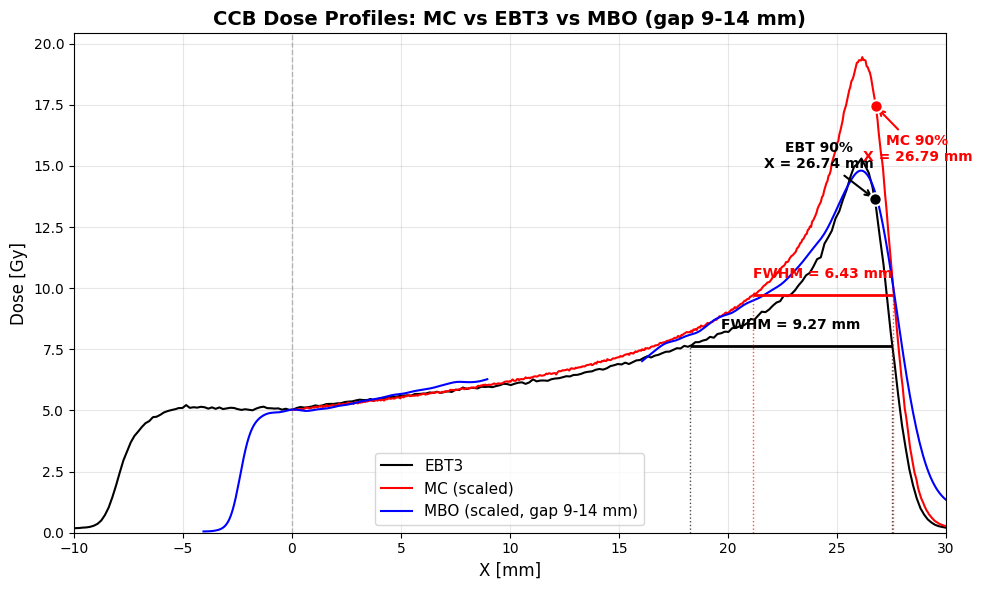

In [6]:
# Plot MC, EBT and MBO dose profiles - MBO with gap (9-14 mm excluded)
fig, ax = plt.subplots(figsize=(10, 6))

# Plot EBT data (black color)
ax.plot(df_ebt['x_mm'], df_ebt['dose_Gy'], 
        color='black', linewidth=1.5, label='EBT3')

# Plot MC data (scaled, red color)
ax.plot(df_mc['depth'], df_mc['dose_scaled'], 
        color='red', linewidth=1.5, label='MC (scaled)')

# Plot MBO data with gap (9-14 mm excluded)
mbo_values_with_gap = mbo_values_scaled.copy()
gap_mask = (mbo_x_shifted >= 9) & (mbo_x_shifted <= 16)
mbo_values_with_gap[gap_mask] = np.nan

ax.plot(mbo_x_shifted, mbo_values_with_gap, 
        color='blue', linewidth=1.5, label='MBO (scaled, gap 9-14 mm)')

# Mark the reference point at X=0
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Create dense grids for interpolation
x_dense = np.linspace(df_ebt['x_mm'].min(), df_ebt['x_mm'].max(), 1000)
ebt_dense = ebt_interp(x_dense)

mc_interp_scaled = interp1d(df_mc['depth'], df_mc['dose_scaled'], kind='linear', fill_value='extrapolate')
x_dense_mc = np.linspace(df_mc['depth'].min(), df_mc['depth'].max(), 1000)
mc_dense = mc_interp_scaled(x_dense_mc)

# --- FWHM for EBT ---
ebt_max = df_ebt['dose_Gy'].max()
ebt_half_max = ebt_max / 2

above_half_ebt = ebt_dense >= ebt_half_max
transitions_ebt = np.diff(above_half_ebt.astype(int))
rising_idx_ebt = np.where(transitions_ebt == 1)[0]
falling_idx_ebt = np.where(transitions_ebt == -1)[0]

if len(rising_idx_ebt) > 0 and len(falling_idx_ebt) > 0:
    fwhm_left_ebt = x_dense[rising_idx_ebt[0]]
    fwhm_right_ebt = x_dense[falling_idx_ebt[-1]]
    fwhm_value_ebt = fwhm_right_ebt - fwhm_left_ebt
    
    ax.hlines(y=ebt_half_max, xmin=fwhm_left_ebt, xmax=fwhm_right_ebt, 
              colors='black', linestyles='-', linewidth=2)
    ax.vlines(x=[fwhm_left_ebt, fwhm_right_ebt], ymin=0, ymax=ebt_half_max, 
              colors='black', linestyles=':', linewidth=1, alpha=0.7)
    ax.annotate(f'FWHM = {fwhm_value_ebt:.2f} mm', 
                xy=((fwhm_left_ebt + fwhm_right_ebt) / 2, ebt_half_max),
                xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, color='black',
                fontweight='bold')

# --- FWHM for MC ---
mc_max = df_mc['dose_scaled'].max()
mc_half_max = mc_max / 2

above_half_mc = mc_dense >= mc_half_max
transitions_mc = np.diff(above_half_mc.astype(int))
rising_idx_mc = np.where(transitions_mc == 1)[0]
falling_idx_mc = np.where(transitions_mc == -1)[0]

if len(rising_idx_mc) > 0 and len(falling_idx_mc) > 0:
    fwhm_left_mc = x_dense_mc[rising_idx_mc[0]]
    fwhm_right_mc = x_dense_mc[falling_idx_mc[-1]]
    fwhm_value_mc = fwhm_right_mc - fwhm_left_mc
    
    ax.hlines(y=mc_half_max, xmin=fwhm_left_mc, xmax=fwhm_right_mc, 
              colors='red', linestyles='-', linewidth=2)
    ax.vlines(x=[fwhm_left_mc, fwhm_right_mc], ymin=0, ymax=mc_half_max, 
              colors='red', linestyles=':', linewidth=1, alpha=0.7)
    ax.annotate(f'FWHM = {fwhm_value_mc:.2f} mm', 
                xy=((fwhm_left_mc + fwhm_right_mc) / 2, mc_half_max),
                xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, color='red',
                fontweight='bold')

# --- Find 90% dose point on distal part for EBT ---
dose_90_ebt = 0.9 * ebt_max
idx_max_ebt = np.argmax(ebt_dense)
x_max_ebt = x_dense[idx_max_ebt]
distal_mask_ebt = x_dense > x_max_ebt
x_distal_ebt = x_dense[distal_mask_ebt]
ebt_distal = ebt_dense[distal_mask_ebt]

below_90_ebt = ebt_distal < dose_90_ebt
if np.any(below_90_ebt):
    idx_90_ebt = np.where(below_90_ebt)[0][0]
    x_90_ebt = x_distal_ebt[idx_90_ebt]
    dose_at_90_ebt = ebt_distal[idx_90_ebt]
    
    ax.scatter([x_90_ebt], [dose_at_90_ebt], color='black', s=80, zorder=5, marker='o', edgecolors='white', linewidths=1.5)
    ax.annotate(f'EBT 90%\nX = {x_90_ebt:.2f} mm', 
                xy=(x_90_ebt, dose_at_90_ebt),
                xytext=(-40, 20), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, color='black',
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# --- Find 90% dose point on distal part for MC ---
dose_90_mc = 0.9 * mc_max
idx_max_mc = np.argmax(mc_dense)
x_max_mc = x_dense_mc[idx_max_mc]
distal_mask_mc = x_dense_mc > x_max_mc
x_distal_mc = x_dense_mc[distal_mask_mc]
mc_distal = mc_dense[distal_mask_mc]

below_90_mc = mc_distal < dose_90_mc
if np.any(below_90_mc):
    idx_90_mc = np.where(below_90_mc)[0][0]
    x_90_mc = x_distal_mc[idx_90_mc]
    dose_at_90_mc = mc_distal[idx_90_mc]
    
    ax.scatter([x_90_mc], [dose_at_90_mc], color='red', s=80, zorder=5, marker='o', edgecolors='white', linewidths=1.5)
    ax.annotate(f'MC 90%\nX = {x_90_mc:.2f} mm', 
                xy=(x_90_mc, dose_at_90_mc),
                xytext=(30, -20), textcoords='offset points',
                ha='center', va='top', fontsize=10, color='red',
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_xlabel('X [mm]', fontsize=12)
ax.set_ylabel('Dose [Gy]', fontsize=12)
ax.set_title('CCB Dose Profiles: MC vs EBT3 vs MBO (gap 9-14 mm)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 30)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

In [7]:
# Calculate profile parameters for summary table

def find_distal_position(x_dense, y_dense, threshold_fraction):
    """Find position on distal edge where dose drops to threshold_fraction of max."""
    y_max = y_dense.max()
    threshold = threshold_fraction * y_max
    idx_max = np.argmax(y_dense)
    x_max = x_dense[idx_max]
    
    # Look only in distal part (X > position of max)
    distal_mask = x_dense > x_max
    x_distal = x_dense[distal_mask]
    y_distal = y_dense[distal_mask]
    
    below_threshold = y_distal < threshold
    if np.any(below_threshold):
        idx = np.where(below_threshold)[0][0]
        return x_distal[idx]
    return np.nan

def calc_penumbra_80_20(x_dense, y_dense):
    """Calculate distance from 80% to 20% dose on distal edge."""
    x_80 = find_distal_position(x_dense, y_dense, 0.8)
    x_20 = find_distal_position(x_dense, y_dense, 0.2)
    if np.isnan(x_80) or np.isnan(x_20):
        return np.nan
    return x_20 - x_80

def calc_fwhm(x_dense, y_dense):
    """Calculate FWHM."""
    y_max = y_dense.max()
    half_max = y_max / 2
    above_half = y_dense >= half_max
    transitions = np.diff(above_half.astype(int))
    rising_idx = np.where(transitions == 1)[0]
    falling_idx = np.where(transitions == -1)[0]
    if len(rising_idx) > 0 and len(falling_idx) > 0:
        return x_dense[falling_idx[-1]] - x_dense[rising_idx[0]]
    return np.nan

# Recreate dense interpolations
x_dense_ebt = np.linspace(df_ebt['x_mm'].min(), df_ebt['x_mm'].max(), 1000)
ebt_dense = ebt_interp(x_dense_ebt)

mc_interp_scaled = interp1d(df_mc['depth'], df_mc['dose_scaled'], kind='linear', fill_value='extrapolate')
x_dense_mc = np.linspace(df_mc['depth'].min(), df_mc['depth'].max(), 1000)
mc_dense = mc_interp_scaled(x_dense_mc)

mbo_interp_scaled = interp1d(mbo_x_shifted, mbo_values_scaled, kind='linear', fill_value='extrapolate')
x_dense_mbo = np.linspace(mbo_x_shifted.min(), mbo_x_shifted.max(), 1000)
mbo_dense = mbo_interp_scaled(x_dense_mbo)

# Calculate parameters for each profile
profiles = {
    'EBT3': (x_dense_ebt, ebt_dense, df_ebt['dose_Gy'].max(), ebt_dose_at_0),
    'MC': (x_dense_mc, mc_dense, df_mc['dose_scaled'].max(), float(mc_interp_scaled(0))),
    'MBO': (x_dense_mbo, mbo_dense, mbo_values_scaled.max(), float(mbo_interp_scaled(0)))
}

results = []
for name, (x_d, y_d, max_dose, dose_at_0) in profiles.items():
    fwhm = calc_fwhm(x_d, y_d)
    range_90 = find_distal_position(x_d, y_d, 0.9)
    max_to_0_ratio = max_dose / dose_at_0
    penumbra_80_20 = calc_penumbra_80_20(x_d, y_d)
    
    results.append({
        'Profile': name,
        'FWHM [mm]': f"{fwhm:.2f}",
        'Range (90%) [mm]': f"{range_90:.2f}",
        'Max/Dose@X=0': f"{max_to_0_ratio:.3f}",
        'Penumbra 80-20% [mm]': f"{penumbra_80_20:.2f}"
    })

# Create and display table
df_summary = pd.DataFrame(results)
print("Profile Parameters Summary")
print("=" * 70)
display(df_summary)

Profile Parameters Summary


,Profile,FWHM [mm],Range (90%) [mm],Max/Dose@X=0,Penumbra 80-20% [mm]
0,EBT3,9.32,26.74,3.040,1.25
1,MC,6.46,26.79,3.864,1.28
2,MBO,11.43,26.98,2.942,1.76
